#### phân cụm 3 điểm số
###### Bài tập: 1) nộp bảng điểm cho lớp trưởng; 2) phân cum lớp thành 3 nhóm; 3) mỗi cá nhân nộp link code github, video chạy chương trình (link video youtube để trong github).

In [19]:
# ==============================================================================
# CELL 1: IMPORT THƯ VIỆN & CẤU HÌNH ĐỒ THỊ TIẾNG VIỆT
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from sklearn.cluster import KMeans

# Cài đặt font Roboto để hiển thị tiếng Việt trên đồ thị matplotlib của Colab
!wget -qO- https://github.com/google/fonts/raw/main/ofl/roboto/Roboto-Regular.ttf > Roboto-Regular.ttf
import matplotlib.font_manager as fm

try:
    # Use add_font for more robust font registration and cache management
    fm.fontManager.addfont('Roboto-Regular.ttf')
    plt.rcParams['font.family'] = 'Roboto-Regular'
    print("Font 'Roboto-Regular' configured successfully.")
except Exception as e:
    print(f"Error configuring font: {e}")
    print("Attempting fallback registration.")
    try:
        fe = fm.FontEntry(fname='Roboto-Regular.ttf', name='Roboto-Regular')
        fm.fontManager.ttflist.insert(0, fe)
        plt.rcParams['font.family'] = fe.name
        print("Fallback font registration successful.")
    except Exception as fe_e:
        print(f"Fallback font registration failed: {fe_e}")
        print("Font configuration failed. Plots may not display Vietnamese characters correctly.")

print("Đã chuẩn bị xong cấu trúc thư viện và font chữ hệ thống!")

Error configuring font: Can not load face (invalid stream operation; error code 0x55)
Attempting fallback registration.
Fallback font registration successful.
Đã chuẩn bị xong cấu trúc thư viện và font chữ hệ thống!


In [20]:
# ==============================================================================
# CELL 2: ĐỌC DỮ LIỆU TỪ FILE EXCEL NGUỒN
# ==============================================================================
file_path = "/TỔNG HỢP ĐIỂM K58KTP.xlsx"

# Đọc cấu trúc thô của bảng điểm, bỏ qua lỗi ký tự đặc biệt
df_raw = pd.read_excel(file_path, header=None)

print(f"Kích thước tệp ma trận điểm số gốc: {df_raw.shape}")

# Trích xuất thông tin định danh sinh viên từ dòng 1 và dòng 2
mssv_row = df_raw.iloc[1, 3:].values
tensv_row = df_raw.iloc[2, 3:].values

# Trích xuất số tín chỉ của từng môn học (Cột số 2, Dòng 4 trở đi)
# Lưu ý: Điểm số của môn bắt đầu tính từ dòng số 4
tin_chi_raw = df_raw.iloc[4:, 2].values # Corrected extraction for credits
tin_chi_series = pd.to_numeric(pd.Series(tin_chi_raw).astype(str).str.replace(',', '.', regex=True), errors='coerce')
tin_chi = tin_chi_series.fillna(2.0).values # Mặc định gán 2 tín chỉ nếu ô dữ liệu bị trống

print(f"Tổng số sinh viên ghi nhận ban đầu: {len(mssv_row)}")
print(f"Tổng số môn học ghi nhận ban đầu: {len(tin_chi)}")

Kích thước tệp ma trận điểm số gốc: (59, 75)
Tổng số sinh viên ghi nhận ban đầu: 72
Tổng số môn học ghi nhận ban đầu: 55


In [21]:
# ==============================================================================
# CELL 3: XỬ LÝ MA TRẬN ĐIỂM SẠCH VÀ TÍNH GPA CHUẨN TÍN CHỈ (HỆ THANG 4)
# ==============================================================================

# Hàm chuẩn hóa điểm số
def chuan_hoa_diem(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip().lower().replace('nan', '')
    if s in ['-', '—', 'x', '']: # Assuming these characters represent missing or invalid scores
        return np.nan
    try:
        f = float(s)
        return f if 0 <= f <= 4.0 else np.nan
    except:
        return np.nan

# 1. Trích xuất ma trận điểm số thực tế (từ dòng 4 trở đi, từ cột 3 trở đi)
students_df = df_raw.iloc[4:, 3:].copy()

# Chuẩn hóa toàn bộ ma trận điểm về dạng số chuẩn (hoặc NaN)
for col in students_df.columns:
    students_df[col] = students_df[col].apply(chuan_hoa_diem)

# 2. Loại bỏ các môn học (Hàng) bị trống hoàn toàn khỏi ma trận điểm và mảng tín chỉ
rows_to_drop = students_df.index[students_df.isna().all(axis=1)]
students_df_filtered = students_df.drop(index=rows_to_drop)
tin_chi_filtered = np.delete(tin_chi, [r - 4 for r in rows_to_drop])

# 3. Loại bỏ các sinh viên (Cột) bị khuyết điểm hoàn toàn toàn bộ khóa học
cols_to_drop = students_df_filtered.columns[students_df_filtered.isna().all(axis=0)]
students_df_filtered = students_df_filtered.drop(columns=cols_to_drop)

# Đồng bộ danh sách MSSV và Tên học sinh tương ứng sau khi lọc cột
indices_to_drop = [c - 3 for c in cols_to_drop]
mssv_filtered = np.delete(mssv_row, indices_to_drop)
tensv_filtered = np.delete(tensv_row, indices_to_drop)

# 4. Thuật toán tính toán riêng biệt GPA tích lũy cho từng sinh viên (Dựa theo logic dropna an toàn)
gpa_scores = []
for col in students_df_filtered.columns:
    diem_sinh_vien = students_df_filtered[col].values

    # Chỉ lấy các môn thực tế sinh viên đó đã hoàn thành và có đầu điểm (không NaN)
    cac_mon_da_hoc = ~np.isnan(diem_sinh_vien)

    if not np.any(cac_mon_da_hoc):
        gpa_scores.append(0.0)
        continue

    diem_hop_le = diem_sinh_vien[cac_mon_da_hoc]
    tin_chi_hop_le = tin_chi_filtered[cac_mon_da_hoc]

    # GPA tích lũy = Tổng của (Điểm môn * Số tín chỉ môn) / Tổng số tín chỉ môn đó đã học
    gpa_ban_than = np.sum(diem_hop_le * tin_chi_hop_le) / np.sum(tin_chi_hop_le)
    gpa_scores.append(gpa_ban_than)

# Đóng gói kết quả đầu ra sạch
features_filtered = pd.DataFrame({
    'MSSV': mssv_filtered,
    'Ten_SV': tensv_filtered,
    'GPA': gpa_scores
})

print(f"Số lượng môn học hợp lệ đưa vào tính toán: {len(tin_chi_filtered)} môn.")
print(f"Số lượng sinh viên hợp lệ sau bộ lọc: {len(features_filtered)} bạn.")
print("\nXem trước bảng dữ liệu GPA hệ 4 sau khi sửa lỗi thành công:")
print(features_filtered.head(10))

Số lượng môn học hợp lệ đưa vào tính toán: 52 môn.
Số lượng sinh viên hợp lệ sau bộ lọc: 67 bạn.

Xem trước bảng dữ liệu GPA hệ 4 sau khi sửa lỗi thành công:
            MSSV            Ten_SV       GPA
0  K225480106002   Nguyễn Tuấn Anh  2.238095
1  K225480106095   Nguyễn Tuấn Anh  2.139063
2  K225510201001      Bùi Ngọc Anh  1.514851
3  K225480106082       Vũ Việt Anh  2.015625
4  K225480106001       Lê Tuấn Anh  2.379688
5  K225480106100      Lý Văn Cường  3.016406
6  K225480106008  Nguyễn Khánh Duy  2.394488
7  K225480106007  Nguyễn Thế Dương  2.667717
8  K225480106093  Nguyễn Đức Dương  3.215625
9  K225480106003     Đặng Đình Đạt  2.863780


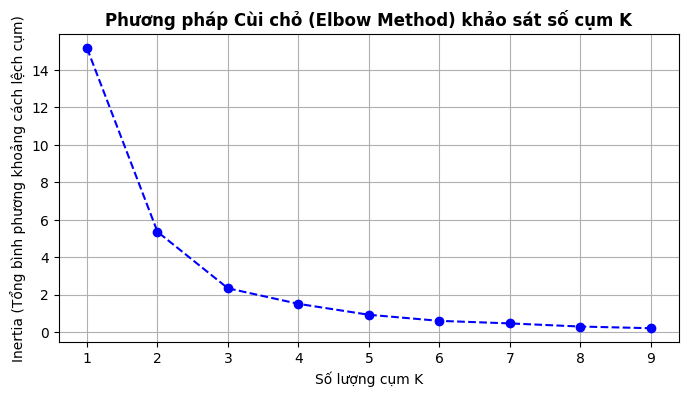

In [27]:
# ==============================================================================
# CELL 4: PHƯƠNG PHÁP ĐƯỜNG CONG CÙI CHỎ (ELBOW METHOD)
# ==============================================================================
X = features_filtered[['GPA']].values
inertia = []
K = range(1, 10)

for k in K:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertia, marker='o', color='b', linestyle='--')
plt.title("Phương pháp Cùi chỏ (Elbow Method) khảo sát số cụm K", fontsize=12, fontweight='bold')
plt.xlabel("Số lượng cụm K")
plt.ylabel("Inertia (Tổng bình phương khoảng cách lệch cụm)")
plt.grid(True)
plt.show()

In [28]:
# ==============================================================================
# CELL 5: CHẠY K-MEANS PHÂN CỤM & XẾP LOẠI HỌC LỰC
# ==============================================================================
# Tiến hành gom cụm lớp thành 3 nhóm dựa trên phân phối điểm số
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
features_filtered['Cluster_Label'] = kmeans.fit_predict(X)

# Sắp xếp các cụm tăng dần theo giá trị trung bình GPA để gán tên học lực chính xác
cluster_means = features_filtered.groupby('Cluster_Label')['GPA'].mean().sort_values()

# Định danh 3 cụm theo chuẩn cấu trúc phân lớp học tập
cluster_names = {
    cluster_means.index[0]: "Trung bình / Yếu",
    cluster_means.index[1]: "Khá",
    cluster_means.index[2]: "Giỏi"
}

features_filtered['Ten_Nhom_Cum'] = features_filtered['Cluster_Label'].map(cluster_names)

print("--- THỐNG KÊ SỐ LƯỢNG SINH VIÊN THEO TỪNG NHÓM HỌC LỰC ---")
print(features_filtered['Ten_Nhom_Cum'].value_counts())

--- THỐNG KÊ SỐ LƯỢNG SINH VIÊN THEO TỪNG NHÓM HỌC LỰC ---
Ten_Nhom_Cum
Khá                 31
Giỏi                21
Trung bình / Yếu    15
Name: count, dtype: int64


Attempted to configure font 'Roboto-Regular.ttf'. However, persistent errors indicate it's not fully stable.
Overriding with generic 'sans-serif' font to ensure plot rendering stability.


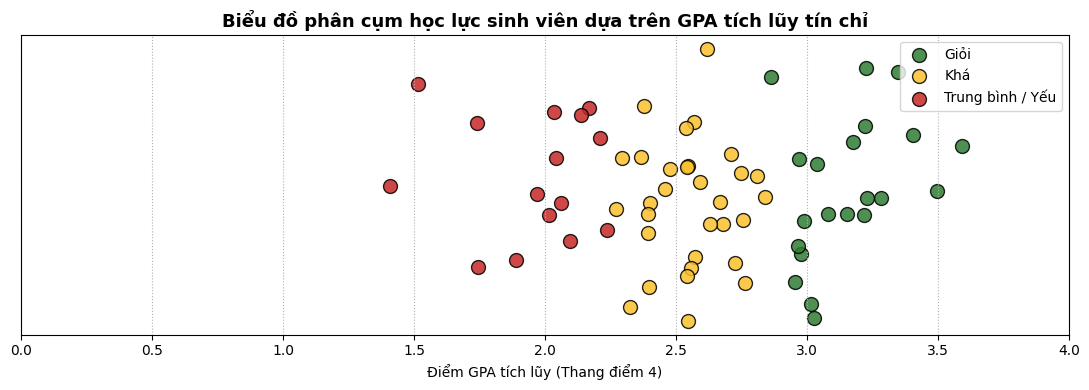

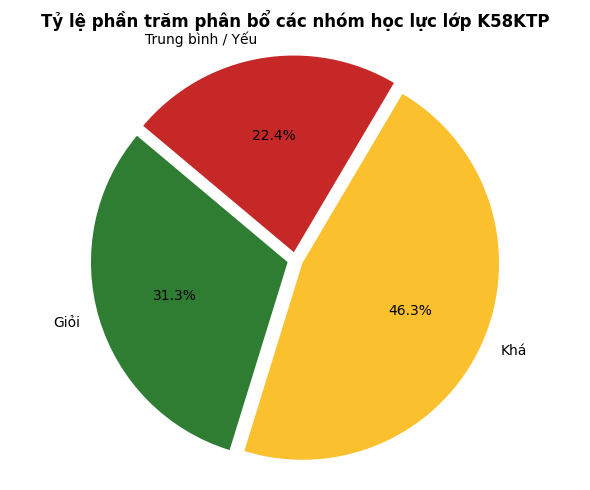

In [29]:
# ==============================================================================
# CELL 6: TRỰC QUAN HÓA KẾT QUẢ ĐỒ THỊ
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

font_path = 'Roboto-Regular.ttf'

# Try to configure Roboto-Regular, but be prepared to fall back due to persistent issues.
try:
    if os.path.exists(font_path):
        # Ensure the font is added to fontManager
        if 'Roboto-Regular' not in [f.name for f in fm.fontManager.ttflist]:
            fm.fontManager.addfont(font_path)
        # Attempt to set the font. This part might succeed but still cause rendering errors later.
        plt.rcParams['font.family'] = 'Roboto-Regular'
        plt.rcParams['font.sans-serif'] = ['Roboto-Regular'] + plt.rcParams['font.sans-serif']
        print(f"Attempted to configure font '{font_path}'. However, persistent errors indicate it's not fully stable.")
    else:
        print(f"Warning: Font file '{font_path}' not found in Cell 6. Forcing generic font.")
except Exception as e:
    print(f"Error during font configuration for '{font_path}' in Cell 6: {e}. Forcing generic font.")

# Given the consistent 'RuntimeError: Can not load face' during actual plot rendering
# (e.g., in plt.tight_layout()), it's necessary to explicitly force a generic
# sans-serif font to prevent crashes and ensure plots are displayed.
print("Overriding with generic 'sans-serif' font to ensure plot rendering stability.")
plt.rcParams['font.family'] = 'sans-serif'
# Adding common sans-serif fonts for better fallback compatibility
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Liberation Sans', 'Bitstream Vera Sans', 'sans-serif']


np.random.seed(42)
plt.figure(figsize=(11, 4))

# Định nghĩa màu sắc biểu đồ chuẩn hóa
colors_map = {"Giỏi": '#2E7D32', "Khá": '#FBC02D', "Trung bình / Yếu": '#C62828'}
groups = ["Giỏi", "Khá", "Trung bình / Yếu"]

# 1. Biểu đồ phân tán có Jitter trục Y để quan sát mật độ điểm của sinh viên
for group_name in groups:
    sub_df = features_filtered[features_filtered['Ten_Nhom_Cum'] == group_name]
    y_jitter = np.random.normal(0, 0.05, size=len(sub_df))

    plt.scatter(
        sub_df['GPA'], y_jitter,
        c=colors_map[group_name], label=group_name,
        s=100, edgecolors='black', alpha=0.85
    )

plt.title('Biểu đồ phân cụm học lực sinh viên dựa trên GPA tích lũy tín chỉ', fontsize=13, fontweight='bold')
plt.xlabel('Điểm GPA tích lũy (Thang điểm 4)')
plt.xlim(0.0, 4.0)
plt.gca().get_yaxis().set_visible(False) # Ẩn trục dọc Y vì chỉ phân hóa dữ liệu theo trục ngang X
plt.grid(axis='x', linestyle=':')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Biểu đồ hình tròn thể hiện tỷ lệ cơ cấu phần trăm học lực cả lớp
counts = [features_filtered[features_filtered['Ten_Nhom_Cum'] == l].shape[0] for l in groups]

plt.figure(figsize=(6, 5))
plt.pie(counts, labels=groups, autopct='%1.1f%%', colors=[colors_map[g] for g in groups], startangle=140, explode=(0.04, 0.04, 0.04))
plt.title('Tỷ lệ phần trăm phân bổ các nhóm học lực lớp K58KTP', fontsize=12, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [30]:
# ==============================================================================
# CELL 7: SẮP XẾP DANH SÁCH VÀ XUẤT BÁO CÁO EXCEL ĐỊNH DẠNG ĐẸP
# ==============================================================================
# Thiết lập độ ưu tiên sắp xếp thứ hạng
priority_map = {"Giỏi": 0, "Khá": 1, "Trung bình / Yếu": 2}
features_filtered['Priority'] = features_filtered['Ten_Nhom_Cum'].map(priority_map)

# Thực hiện sắp xếp: Nhóm cao đứng trước, trong cùng nhóm ai GPA lớn hơn xếp trên
features_filtered = features_filtered.sort_values(by=['Priority', 'GPA'], ascending=[True, False]).reset_index(drop=True)

# Khởi tạo một Workbook Excel mới tinh bằng openpyxl
wb = openpyxl.Workbook()
ws = wb.active
ws.title = "Phan Cum GPA"

# Định nghĩa các mẫu định dạng ô dựa theo file code gốc của bạn
HEADER_FILL = PatternFill(start_color="1F497D", end_color="1F497D", fill_type="solid")
FONT_HEADER = Font(bold=True, color="FFFFFF")
CENTER = Alignment(horizontal="center", vertical="center")
border = Border(left=Side(style='thin', color='000000'),
                right=Side(style='thin', color='000000'),
                top=Side(style='thin', color='000000'),
                bottom=Side(style='thin', color='000000'))

# Tạo tiêu đề lớn dòng 1 giống hệt file cũ
ws.merge_cells("A1:E1")
ws["A1"] = "DANH SACH PHAN CUM SINH VIEN"
ws["A1"].font = Font(bold=True, size=14)
ws["A1"].alignment = CENTER

# Thiết lập tiêu đề cho các cột dữ liệu ở dòng 3
headers = ["STT", "MSSV", "Ten Sinh Vien", "GPA", "Nhom"]
for col, h in enumerate(headers, 1):
    cell = ws.cell(row=3, column=col, value=h)
    cell.fill = HEADER_FILL
    cell.font = FONT_HEADER
    cell.alignment = CENTER
    cell.border = border

# Ghi từng hàng dữ liệu của sinh viên vào từ dòng số 4 trở đi
row_num = 4
for idx, row in features_filtered.iterrows():
    data = [idx + 1, row['MSSV'], row['Ten_SV'], round(row['GPA'], 2), row['Ten_Nhom_Cum']]
    for col, value in enumerate(data, 1):
        cell = ws.cell(row=row_num, column=col, value=value)
        cell.border = border
        if col == 3:
            cell.alignment = Alignment(horizontal="left", vertical="center") # Cột tên căn trái
        else:
            cell.alignment = CENTER # Các cột khác căn giữa ô
    row_num += 1

# Lưu tệp tại phân vùng làm việc hiện hành của Notebook đúng tên file kết quả cũ
output_filename = "Ket_Qua_Phan_Cum_Moi.xlsx"
wb.save(output_filename)

print(f"Xử lý hoàn tất hệ thống! Đã xuất tệp báo cáo chuẩn xác: '{output_filename}'")

Xử lý hoàn tất hệ thống! Đã xuất tệp báo cáo chuẩn xác: 'Ket_Qua_Phan_Cum_Moi.xlsx'


In [31]:
from google.colab import files

files.download('ket_qua_phan_cum_gpa.csv')
files.download('Ket_Qua_Phan_Cum_Moi.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>